<a href="https://colab.research.google.com/github/elhartw/ML4CHEM/blob/main/chemberta_bbbp_improved_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. GPU Check

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

CUDA available: True
GPU name: Tesla T4


## 2. Install Dependencies

In [2]:
!pip install -q transformers rdkit scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 17.6 MB/s eta 0:00:00


## 3. Load Data

The BBBP (Blood-Brain Barrier Penetration) dataset contains ~2,050 molecules labelled 1 (permeable) or 0 (non-permeable).

In [3]:
import pandas as pd

URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
df = pd.read_csv(URL)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Rows: 2050
Columns: ['num', 'name', 'p_np', 'smiles']


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [4]:
print(df["p_np"].value_counts())
print("\nFraction positive:", df["p_np"].mean().round(3))

p_np
1    1567
0     483
Name: count, dtype: int64

Fraction positive: 0.764


## 4. Canonicalize SMILES

Convert all SMILES to canonical form with RDKit and drop any invalid entries.

In [5]:
from rdkit import Chem

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

df["smiles"] = df["smiles"].apply(canonicalize)

n_before = len(df)
df = df.dropna(subset=["smiles"]).reset_index(drop=True)
print(f"Removed (invalid SMILES): {n_before - len(df)}")
print(f"Remaining: {len(df)} molecules")

[10:36:25] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] Explicit valence for atom # 6 N, 4, is greater than permitted
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] Explicit valence for atom # 6 N, 4, is greater than permitted
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] WARNING: not removing hydrogen atom without neighbors
[10:36:25] Explicit valence for atom # 11 N, 4, is greater than pe

Removed (invalid SMILES): 11
Remaining: 2039 molecules


[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors


## 5. Scaffold Split

Use a stratified Murcko scaffold split (80 / 10 / 10) to prevent data leakage between structurally similar molecules.

In [6]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import numpy as np

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def scaffold_split_stratified(df, frac_test=0.1, frac_val=0.1, seed=42):
    scaffolds = defaultdict(list)
    for idx, smi in enumerate(df["smiles"]):
        scaffold = get_scaffold(smi)
        scaffolds[scaffold].append(idx)

    pos_scaffolds, neg_scaffolds = [], []
    for scaffold, idxs in scaffolds.items():
        labels = [df.iloc[i]["p_np"] for i in idxs]
        if sum(labels) > len(labels) / 2:
            pos_scaffolds.append(idxs)
        else:
            neg_scaffolds.append(idxs)

    rng = np.random.default_rng(seed)
    rng.shuffle(pos_scaffolds)
    rng.shuffle(neg_scaffolds)

    def split_groups(groups, frac_test, frac_val):
        n = len(groups)
        n_test = max(1, int(n * frac_test))
        n_val  = max(1, int(n * frac_val))
        return groups[n_test+n_val:], groups[n_test:n_test+n_val], groups[:n_test]

    pos_train, pos_val, pos_test = split_groups(pos_scaffolds, frac_test, frac_val)
    neg_train, neg_val, neg_test = split_groups(neg_scaffolds, frac_test, frac_val)

    def flatten(groups):
        return [i for g in groups for i in g]

    train_idx = flatten(pos_train) + flatten(neg_train)
    val_idx   = flatten(pos_val)   + flatten(neg_val)
    test_idx  = flatten(pos_test)  + flatten(neg_test)

    return (
        df.iloc[train_idx].reset_index(drop=True),
        df.iloc[val_idx].reset_index(drop=True),
        df.iloc[test_idx].reset_index(drop=True),
    )

In [7]:
train_df, val_df, test_df = scaffold_split_stratified(df)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nClass balance train: {train_df['p_np'].mean():.3f} positive")
print(f"Class balance val:   {val_df['p_np'].mean():.3f} positive")
print(f"Class balance test:  {test_df['p_np'].mean():.3f} positive")

train_scaffolds = set(get_scaffold(s) for s in train_df["smiles"])
test_scaffolds  = set(get_scaffold(s) for s in test_df["smiles"])
overlap = train_scaffolds & test_scaffolds
print(f"\nScaffold overlap train/test: {len(overlap)} (should be 0)")

[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not removing hydrogen atom without neighbors
[10:36:26] WARNING: not r

Train: 1584 | Val: 169 | Test: 286

Class balance train: 0.759 positive
Class balance val:   0.751 positive
Class balance test:  0.808 positive


[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not removing hydrogen atom without neighbors
[10:36:27] WARNING: not r


Scaffold overlap train/test: 0 (should be 0)


[10:36:28] WARNING: not removing hydrogen atom without neighbors


In [8]:
train_smiles = train_df["smiles"].tolist()
train_labels = train_df["p_np"].astype(int).tolist()

val_smiles   = val_df["smiles"].tolist()
val_labels   = val_df["p_np"].astype(int).tolist()

test_smiles  = test_df["smiles"].tolist()
test_labels  = test_df["p_np"].astype(int).tolist()

## 6. Load Model: ChemBERTa-77M-MTR

Load the pre-trained ChemBERTa tokenizer and sequence classification model. We increase the classifier dropout to 0.3 to reduce overfitting.

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaConfig

MODEL_NAME = "DeepChem/ChemBERTa-77M-MTR"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config = RobertaConfig.from_pretrained(MODEL_NAME, num_labels=2, classifier_dropout=0.3)
model  = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)

print("Model loaded:", MODEL_NAME)
print("Classifier dropout:", config.classifier_dropout)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                             | Status     | 
--------------------------------+------------+-
regression.out_proj.weight      | UNEXPECTED | 
norm_std                        | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
regression.dense.bias           | UNEXPECTED | 
regression.out_proj.bias        | UNEXPECTED | 
norm_mean                       | UNEXPECTED | 
regression.dense.weight         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: DeepChem/ChemBERTa-77M-MTR
Classifier dropout: 0.3


## 7. SMILES Augmentation

Randomly re-number atom order to generate alternative valid SMILES for the same molecule. Applied with 50% probability during training.

In [10]:
import random

def randomize_smiles(smiles, n_tries=5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for _ in range(n_tries):
        atom_order = list(range(mol.GetNumAtoms()))
        random.shuffle(atom_order)
        new_mol = Chem.RenumberAtoms(mol, atom_order)
        new_smi = Chem.MolToSmiles(new_mol, canonical=False)
        if new_smi and new_smi != smiles:
            return new_smi
    return smiles

# Example
aspirin = "CC(=O)Oc1ccccc1C(=O)O"
print("Original:", aspirin)
for i in range(3):
    print(f"Augmentation {i+1}:", randomize_smiles(aspirin))

Original: CC(=O)Oc1ccccc1C(=O)O
Augmentation 1: c1cc(C(O)=O)c(OC(C)=O)cc1
Augmentation 2: c1cc(OC(=O)C)c(C(O)=O)cc1
Augmentation 3: O(c1c(C(=O)O)cccc1)C(C)=O


## 8. Dataset Class with Augmentation

In [11]:
import torch
from torch.utils.data import Dataset

class SMILESDataset(Dataset):
    def __init__(self, smiles, labels, tokenizer, max_length=128, augment=False):
        self.smiles     = smiles
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.augment    = augment  # True only for the training set

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smi = self.smiles[idx]
        if self.augment and random.random() < 0.5:
            smi = randomize_smiles(smi)

        enc = self.tokenizer(
            smi,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = SMILESDataset(train_smiles, train_labels, tokenizer, augment=True)
val_ds   = SMILESDataset(val_smiles,   val_labels,   tokenizer, augment=False)
test_ds  = SMILESDataset(test_smiles,  test_labels,  tokenizer, augment=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1584 | Val: 169 | Test: 286


## 9. Class Weights

The dataset is imbalanced (~84% positive). Balanced class weights up-weight the minority class in the loss function.

In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights_tensor)

Class weights: tensor([2.0733, 0.6589])


## 10. Custom Trainer with Weighted Loss + Label Smoothing

In [13]:
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    """Extends HuggingFace Trainer with weighted cross-entropy and label smoothing."""
    def __init__(self, class_weights, label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.class_weights   = class_weights
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            label_smoothing=self.label_smoothing,
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

model.safetensors:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

## 11. Evaluation Metrics

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        "accuracy": accuracy_score(labels, preds),
        "roc_auc":  roc_auc_score(labels, probs),
    }

## 12. Training

Key choices: cosine LR schedule, 20 epochs, fp16, best model selected by ROC-AUC on the validation set.

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./chemberta_bbbp_v2",
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
    logging_steps=20,
    save_total_limit=2,
    report_to="none",
    fp16=True,
)

trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    label_smoothing=0.1,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Roc Auc
1,0.706954,0.720152,0.733728,0.852081
2,0.689487,0.700882,0.775148,0.873453
3,0.657615,0.676251,0.781065,0.871016
4,0.632061,0.644162,0.792899,0.868579
5,0.599505,0.609659,0.810651,0.868766
6,0.567141,0.583033,0.852071,0.864454
7,0.547755,0.565305,0.857988,0.863142
8,0.509030,0.559691,0.863905,0.867829
9,0.524976,0.555808,0.852071,0.872891
10,0.526385,0.552109,0.863905,0.879078


[10:37:10] WARNING: not removing hydrogen atom without neighbors
[10:37:10] WARNING: not removing hydrogen atom without neighbors
[10:37:10] WARNING: not removing hydrogen atom without neighbors
[10:37:10] WARNING: not removing hydrogen atom without neighbors
[10:37:11] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:12] WARNING: not removing hydrogen atom without neighbors
[10:37:13] WARNING: not r

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[10:37:15] WARNING: not removing hydrogen atom without neighbors
[10:37:15] WARNING: not removing hydrogen atom without neighbors
[10:37:15] WARNING: not removing hydrogen atom without neighbors
[10:37:16] WARNING: not removing hydrogen atom without neighbors
[10:37:16] WARNING: not removing hydrogen atom without neighbors
[10:37:16] WARNING: not removing hydrogen atom without neighbors
[10:37:16] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not removing hydrogen atom without neighbors
[10:37:17] WARNING: not r

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[10:38:00] WARNING: not removing hydrogen atom without neighbors
[10:38:00] WARNING: not removing hydrogen atom without neighbors
[10:38:00] WARNING: not removing hydrogen atom without neighbors
[10:38:00] WARNING: not removing hydrogen atom without neighbors
[10:38:00] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors
[10:38:01] WARNING: not removing hydrogen atom without neighbors


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.beta', 'roberta.embeddings.LayerNorm.gamma', 'roberta.encoder.layer.0.attention.output.LayerNorm.beta', 'roberta.enc

TrainOutput(global_step=1000, training_loss=0.5527291593551635, metrics={'train_runtime': 54.3519, 'train_samples_per_second': 582.868, 'train_steps_per_second': 18.399, 'total_flos': 72982593699840.0, 'train_loss': 0.5527291593551635, 'epoch': 20.0})

## 13. Threshold Tuning

Search for the classification threshold that maximises macro F1 on the **validation set**, then apply it to the test set.

In [17]:
from sklearn.metrics import f1_score
import numpy as np

val_predictions = trainer.predict(val_ds)
val_probs_tuning = torch.softmax(torch.tensor(val_predictions.predictions), dim=-1)[:, 1].numpy()
val_labels_tuning = val_predictions.label_ids

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [
    f1_score(val_labels_tuning, (val_probs_tuning >= t).astype(int), average='macro')
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Optimal threshold (on validation set): {best_threshold:.3f}")
print(f"Macro F1 at this threshold:            {best_f1:.4f}")

Optimal threshold (on validation set): 0.470
Macro F1 at this threshold:            0.8551


## 14. Evaluation on Test Set

Report metrics at the default threshold (0.5) and at the tuned threshold found in the previous step.

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

test_predictions = trainer.predict(test_ds)
test_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=-1)[:, 1].numpy()
test_labels_eval = test_predictions.label_ids

# --- Default threshold (0.5) ---
print("=== Test results - default threshold (0.5) ===")
y_pred_default = (test_probs >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(test_labels_eval, y_pred_default):.4f}")
print(f"ROC-AUC:  {roc_auc_score(test_labels_eval, test_probs):.4f}")
print(f"Macro F1: {f1_score(test_labels_eval, y_pred_default, average='macro'):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(test_labels_eval, y_pred_default))
print("\nPer-class metrics:")
print(classification_report(test_labels_eval, y_pred_default, target_names=["BBB- (0)", "BBB+ (1)"]))

# --- Tuned threshold ---
print(f"\n=== Test results - tuned threshold ({best_threshold:.3f}) ===")
y_pred_tuned = (test_probs >= best_threshold).astype(int)
print(f"Accuracy: {accuracy_score(test_labels_eval, y_pred_tuned):.4f}")
print(f"ROC-AUC:  {roc_auc_score(test_labels_eval, test_probs):.4f}")
print(f"Macro F1: {f1_score(test_labels_eval, y_pred_tuned, average='macro'):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(test_labels_eval, y_pred_tuned))
print("\nPer-class metrics:")
print(classification_report(test_labels_eval, y_pred_tuned, target_names=["BBB- (0)", "BBB+ (1)"]))

=== Test results - default threshold (0.5) ===
Accuracy: 0.8636
ROC-AUC:  0.8789
Macro F1: 0.7878

Confusion matrix:
[[ 38  17]
 [ 22 209]]

Per-class metrics:
              precision    recall  f1-score   support

    BBB- (0)       0.63      0.69      0.66        55
    BBB+ (1)       0.92      0.90      0.91       231

    accuracy                           0.86       286
   macro avg       0.78      0.80      0.79       286
weighted avg       0.87      0.86      0.87       286


=== Test results - tuned threshold (0.470) ===
Accuracy: 0.8811
ROC-AUC:  0.8789
Macro F1: 0.8060

Confusion matrix:
[[ 37  18]
 [ 16 215]]

Per-class metrics:
              precision    recall  f1-score   support

    BBB- (0)       0.70      0.67      0.69        55
    BBB+ (1)       0.92      0.93      0.93       231

    accuracy                           0.88       286
   macro avg       0.81      0.80      0.81       286
weighted avg       0.88      0.88      0.88       286



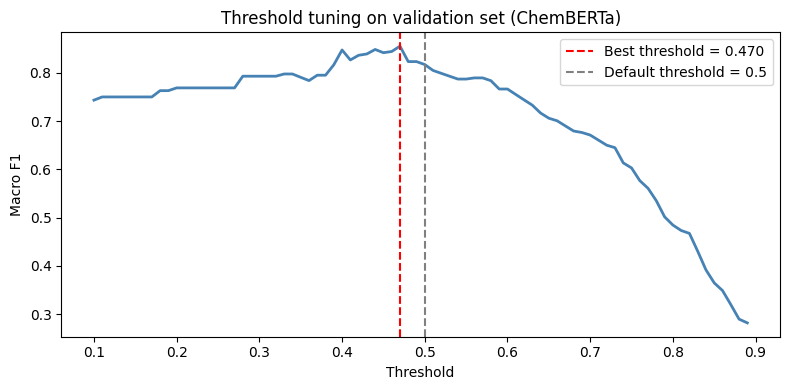

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best threshold = {best_threshold:.3f}')
plt.axvline(x=0.5, color='gray', linestyle='--',
            label='Default threshold = 0.5')
plt.xlabel('Threshold')
plt.ylabel('Macro F1')
plt.title('Threshold tuning on validation set (ChemBERTa)')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning_chemberta.png', dpi=150)
plt.show()

### 15. Architecture Visualisation

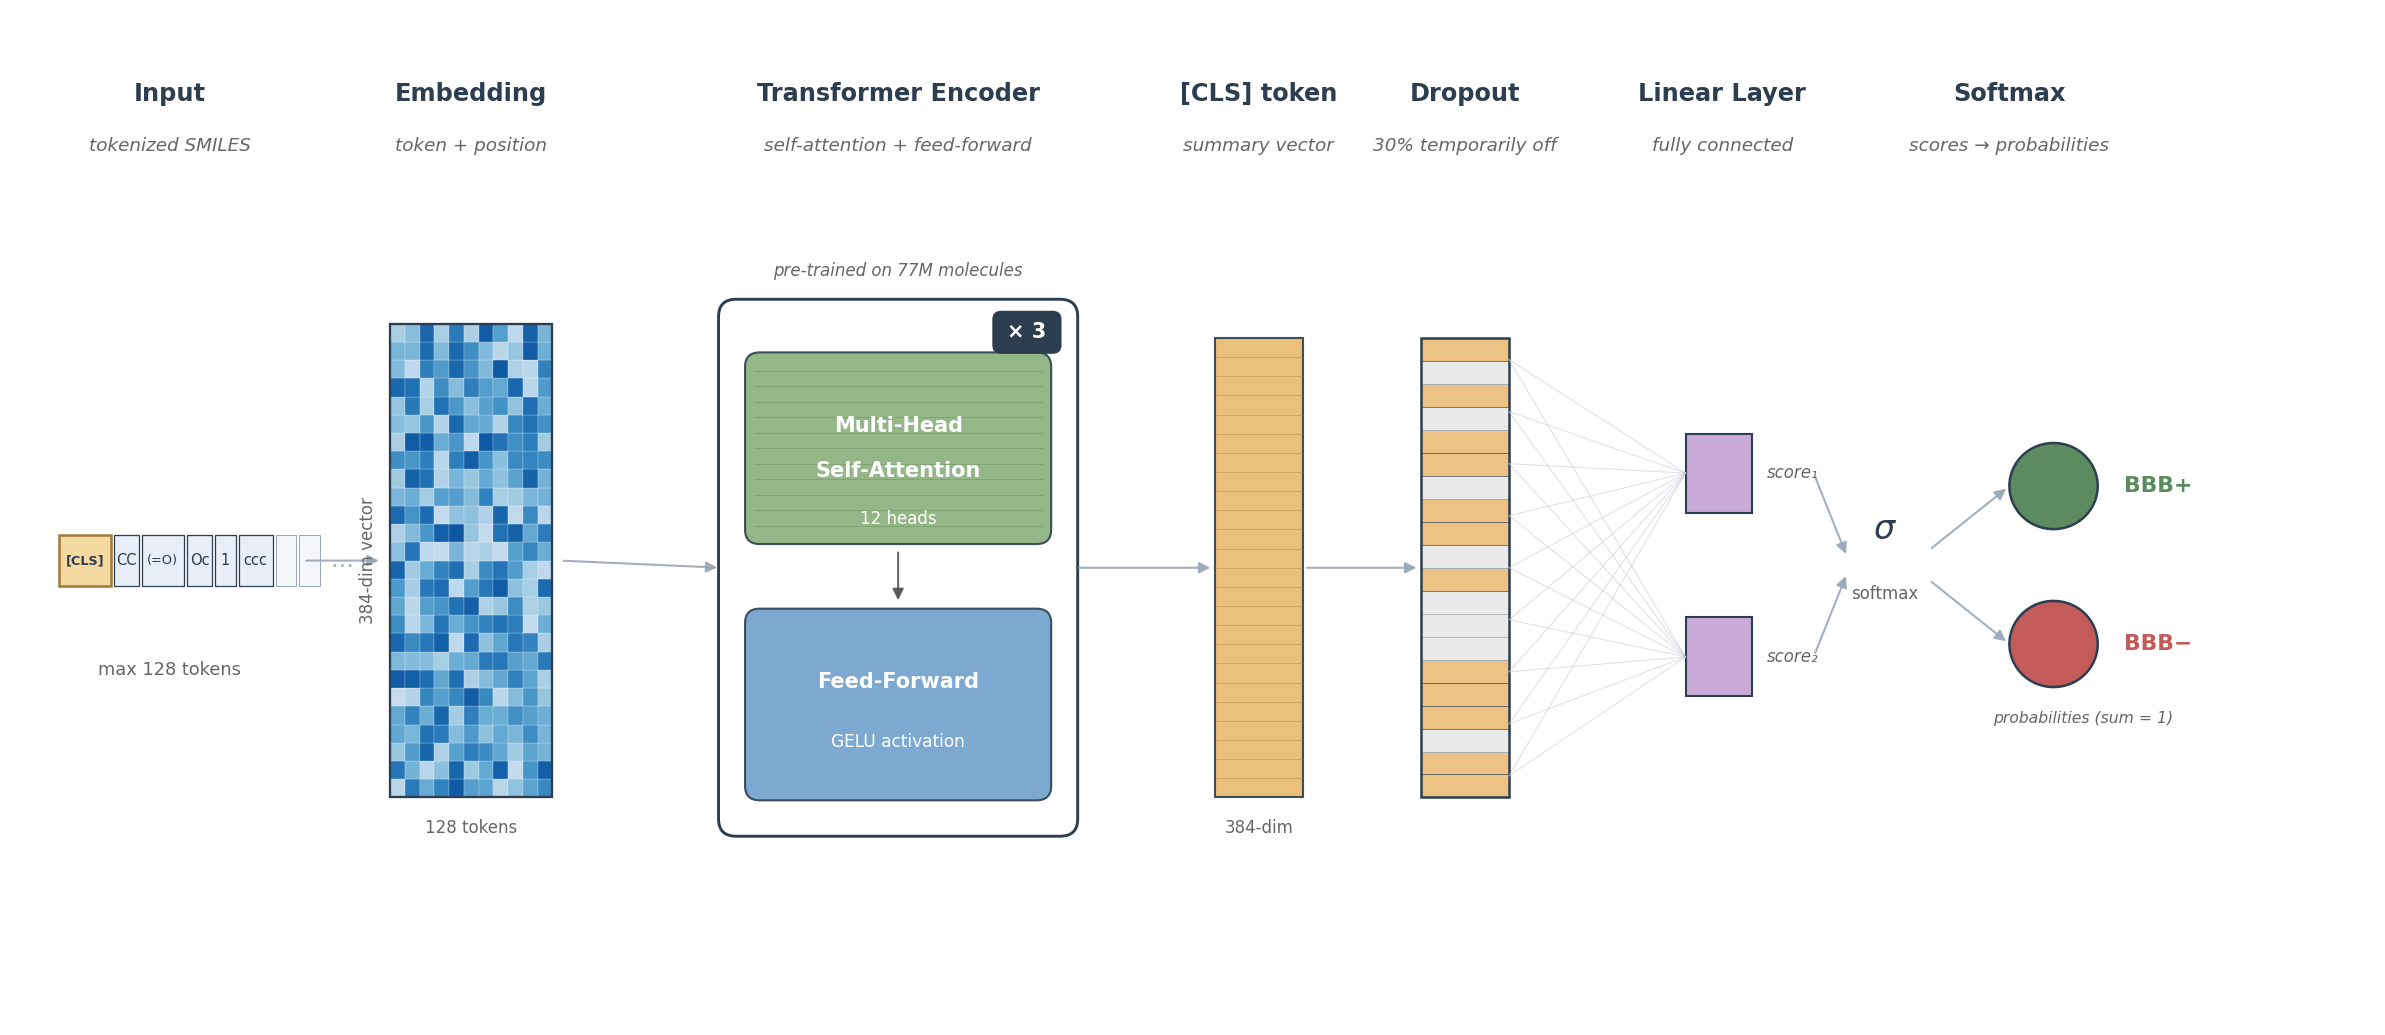

In [20]:
# === Visualization: ChemBERTa-77M-MTR architecture ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch, Circle
import numpy as np

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

COL_INPUT      = "#E8EEF7"
COL_CLS        = "#F4D9A1"; COL_CLS_DK = "#a07a3a"
COL_EMBED_CMAP = plt.cm.Blues
COL_ATTN       = "#88B07A"; COL_ATTN_DK = "#5a7a4c"
COL_FFN        = "#6FA0CC"
COL_POOL       = "#E9B96E"
COL_LOGIT      = "#C9A9D8"
COL_OUT_POS    = "#5B8B5E"; COL_OUT_NEG = "#C45B5B"
EDGE           = "#2c3e50"; EDGE_LIGHT  = "#9aa8b8"
TEXT_DIM       = "#666"

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)
ax.set_xlim(0, 16); ax.set_ylim(0, 7); ax.axis("off")

def arrow(x1, y1, x2, y2, color=EDGE_LIGHT, lw=1.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=11, linewidth=lw, color=color, alpha=0.9))

title_y, sub_y = 6.4, 6.05

# 1. Input: tokenized SMILES
ax.text(1.05, title_y, "Input", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(1.05, sub_y, "tokenized SMILES", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
tokens = ['[CLS]', 'CC', '(=O)', 'Oc', '1', 'ccc']
token_widths = [max(0.14, 0.06 * len(t) + 0.05) for t in tokens]
start_x, in_cy, cell_h, gap = 0.30, 3.2, 0.36, 0.02
x = start_x
for tok, w in zip(tokens, token_widths):
    is_cls = (tok == '[CLS]')
    color = COL_CLS if is_cls else COL_INPUT
    ec = COL_CLS_DK if is_cls else EDGE
    lw = 1.2 if is_cls else 0.6
    ax.add_patch(Rectangle((x, in_cy - cell_h/2), w, cell_h, facecolor=color, edgecolor=ec, linewidth=lw))
    fs = 6.2 if len(tok) > 3 else 7
    ax.text(x + w/2, in_cy, tok, ha="center", va="center", fontsize=fs, color=EDGE,
            fontweight="bold" if is_cls else "normal")
    x += w + gap
for _ in range(2):
    ax.add_patch(Rectangle((x, in_cy - cell_h/2), 0.14, cell_h, facecolor="#F4F6FA",
                           edgecolor=EDGE_LIGHT, linewidth=0.5))
    x += 0.14 + gap
ax.text(x + 0.05, in_cy, "…", ha="left", va="center", fontsize=11, color="#aaa")
ax.text(1.05, 2.4, "max 128 tokens", ha="center", fontsize=8.5, color=TEXT_DIM)

# 2. Embedding
ax.text(3.1, title_y, "Embedding", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(3.1, sub_y, "token + position", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
emb_x, emb_y, emb_w, emb_h = 2.55, 1.55, 1.1, 3.3
n_cols, n_rows = 11, 26
cs_w, cs_h = emb_w/n_cols, emb_h/n_rows
np.random.seed(7)
intens = 0.25 + 0.6*np.random.rand(n_rows, n_cols)
for r in range(n_rows):
    for c in range(n_cols):
        ax.add_patch(Rectangle((emb_x + c*cs_w, emb_y + r*cs_h), cs_w, cs_h,
                               facecolor=COL_EMBED_CMAP(intens[r, c]), edgecolor="white", linewidth=0.1))
ax.add_patch(Rectangle((emb_x, emb_y), emb_w, emb_h, facecolor="none", edgecolor=EDGE, linewidth=1.1))
ax.text(emb_x + emb_w/2, emb_y - 0.25, "128 tokens", ha="center", fontsize=8, color=TEXT_DIM)
ax.text(emb_x - 0.15, emb_y + emb_h/2, "384-dim vector",
        ha="center", va="center", fontsize=8, color=TEXT_DIM, rotation=90)
arrow(1.95, in_cy, 2.5, in_cy)

# 3. Transformer Encoder (× 3)
ax.text(6.0, title_y, "Transformer Encoder", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(6.0, sub_y, "self-attention + feed-forward",
        ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
enc_x, enc_y, enc_w, enc_h = 4.8, 1.3, 2.4, 3.7
ax.add_patch(FancyBboxPatch((enc_x, enc_y), enc_w, enc_h,
    boxstyle="round,pad=0.02,rounding_size=0.12", facecolor="white", edgecolor=EDGE, linewidth=1.4))
# Attention block
attn_y, attn_h = enc_y + enc_h * 0.55, enc_h * 0.35
ax.add_patch(FancyBboxPatch((enc_x + 0.18, attn_y), enc_w - 0.36, attn_h,
    boxstyle="round,pad=0.02,rounding_size=0.10", facecolor=COL_ATTN, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
for s in range(1, 12):
    ys = attn_y + s * attn_h / 12
    ax.plot([enc_x + 0.22, enc_x + enc_w - 0.22], [ys, ys], color=COL_ATTN_DK, linewidth=0.3, alpha=0.5)
ax.text(enc_x + enc_w/2, attn_y + attn_h * 0.62, "Multi-Head",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, attn_y + attn_h * 0.38, "Self-Attention",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, attn_y + attn_h * 0.12, "12 heads",
        ha="center", va="center", fontsize=8, color="white")
# FFN block
ffn_y, ffn_h = enc_y + 0.25, enc_h * 0.35
ax.add_patch(FancyBboxPatch((enc_x + 0.18, ffn_y), enc_w - 0.36, ffn_h,
    boxstyle="round,pad=0.02,rounding_size=0.10", facecolor=COL_FFN, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
ax.text(enc_x + enc_w/2, ffn_y + ffn_h * 0.62, "Feed-Forward",
        ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, ffn_y + ffn_h * 0.30, "GELU activation",
        ha="center", va="center", fontsize=8.2, color="white")
arrow(enc_x + enc_w/2, attn_y - 0.05, enc_x + enc_w/2, ffn_y + ffn_h + 0.05, color="#555", lw=1.0)
# × 3 badge
badge_x, badge_y = enc_x + enc_w - 0.55, enc_y + enc_h - 0.35
ax.add_patch(FancyBboxPatch((badge_x, badge_y), 0.45, 0.28,
    boxstyle="round,pad=0.01,rounding_size=0.06", facecolor=EDGE, edgecolor="none"))
ax.text(badge_x + 0.225, badge_y + 0.14, "× 3", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.text(enc_x + enc_w/2, enc_y + enc_h + 0.18, "pre-trained on 77M molecules",
        ha="center", fontsize=8, color=TEXT_DIM, style="italic")
arrow(3.7, in_cy, enc_x, enc_y + enc_h/2)

# 4. [CLS] token
ax.text(8.45, title_y, "[CLS] token", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(8.45, sub_y, "summary vector", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
cls_x, cls_w, cls_h = 8.15, 0.6, 3.2
cls_y = (enc_y + enc_h/2) - cls_h/2
ax.add_patch(Rectangle((cls_x, cls_y), cls_w, cls_h,
                       facecolor=COL_POOL, edgecolor=EDGE, linewidth=1.0, alpha=0.9))
for s in range(1, 24):
    ys = cls_y + s * cls_h / 24
    ax.plot([cls_x, cls_x + cls_w], [ys, ys], color=COL_CLS_DK, linewidth=0.3, alpha=0.55)
ax.text(cls_x + cls_w/2, cls_y - 0.25, "384-dim", ha="center", fontsize=8, color=TEXT_DIM)
arrow(enc_x + enc_w, enc_y + enc_h/2, cls_x, cls_y + cls_h/2)

# 5. Dropout
ax.text(9.85, title_y, "Dropout", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(9.85, sub_y, "30% temporarily off", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
drop_x, drop_w = 9.55, 0.6
drop_h, drop_y = cls_h, cls_y
n_dots = 20
dot_h = drop_h / n_dots
np.random.seed(3)
off = np.random.rand(n_dots) < 0.30
for i in range(n_dots):
    sy = drop_y + i*dot_h
    color = "#EAEAEA" if off[i] else COL_POOL
    edge_c = EDGE_LIGHT if off[i] else EDGE
    alpha = 1.0 if off[i] else 0.85
    ax.add_patch(Rectangle((drop_x, sy), drop_w, dot_h, facecolor=color,
                           edgecolor=edge_c, linewidth=0.3, alpha=alpha))
ax.add_patch(Rectangle((drop_x, drop_y), drop_w, drop_h, facecolor="none", edgecolor=EDGE, linewidth=1.2))
arrow(cls_x + cls_w, cls_y + cls_h/2, drop_x, drop_y + drop_h/2)

# 6. Linear Layer
ax.text(11.6, title_y, "Linear Layer", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(11.6, sub_y, "fully connected", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
logit_x, logit_w, logit_h = 11.35, 0.45, 0.55
logit_y_t = drop_y + drop_h * 0.62
logit_y_b = drop_y + drop_h * 0.22
for ly in [logit_y_t, logit_y_b]:
    ax.add_patch(Rectangle((logit_x, ly), logit_w, logit_h,
                           facecolor=COL_LOGIT, edgecolor=EDGE, linewidth=1.0))
ax.text(logit_x + logit_w + 0.1, logit_y_t + logit_h/2, "score₁",
        va="center", fontsize=8, color=TEXT_DIM, style="italic")
ax.text(logit_x + logit_w + 0.1, logit_y_b + logit_h/2, "score₂",
        va="center", fontsize=8, color=TEXT_DIM, style="italic")
sample_ys = np.linspace(drop_y + 0.15, drop_y + drop_h - 0.15, 9)
for ly in sample_ys:
    for oy in [logit_y_t + logit_h/2, logit_y_b + logit_h/2]:
        ax.plot([drop_x + drop_w, logit_x], [ly, oy], color="#c0c8d4", linewidth=0.5, alpha=0.55, zorder=1)

# 7. Softmax + output
ax.text(13.55, title_y, "Softmax", ha="center", fontsize=11.5, fontweight="bold", color=EDGE)
ax.text(13.55, sub_y, "scores → probabilities", ha="center", fontsize=8.8, color=TEXT_DIM, style="italic")
sm_x, sm_w = 12.45, 0.5
sm_y_center = (logit_y_t + logit_y_b + logit_h) / 2
ax.text(sm_x + sm_w/2, sm_y_center + 0.25, "σ", ha="center", va="center",
        fontsize=16, color=EDGE, style="italic")
ax.text(sm_x + sm_w/2, sm_y_center - 0.2, "softmax", ha="center", va="center",
        fontsize=8, color=TEXT_DIM)
arrow(logit_x + logit_w + 0.42, logit_y_t + logit_h/2, sm_x, sm_y_center + 0.05)
arrow(logit_x + logit_w + 0.42, logit_y_b + logit_h/2, sm_x, sm_y_center - 0.05)

out_x, out_r = 13.85, 0.3
out_y_t = sm_y_center + 0.55
out_y_b = sm_y_center - 0.55
ax.add_patch(Circle((out_x, out_y_t), out_r, facecolor=COL_OUT_POS, edgecolor=EDGE, linewidth=1.2, zorder=3))
ax.add_patch(Circle((out_x, out_y_b), out_r, facecolor=COL_OUT_NEG, edgecolor=EDGE, linewidth=1.2, zorder=3))
arrow(sm_x + sm_w + 0.05, sm_y_center + 0.1, out_x - out_r, out_y_t)
arrow(sm_x + sm_w + 0.05, sm_y_center - 0.1, out_x - out_r, out_y_b)
ax.text(out_x + out_r + 0.18, out_y_t, "BBB+", va="center", fontsize=10.5, fontweight="bold", color=COL_OUT_POS)
ax.text(out_x + out_r + 0.18, out_y_b, "BBB−", va="center", fontsize=10.5, fontweight="bold", color=COL_OUT_NEG)
ax.text(out_x + 0.2, out_y_b - 0.55, "probabilities (sum = 1)",
        ha="center", fontsize=7.5, color=TEXT_DIM, style="italic")

plt.tight_layout()
plt.savefig("chemberta_architecture.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

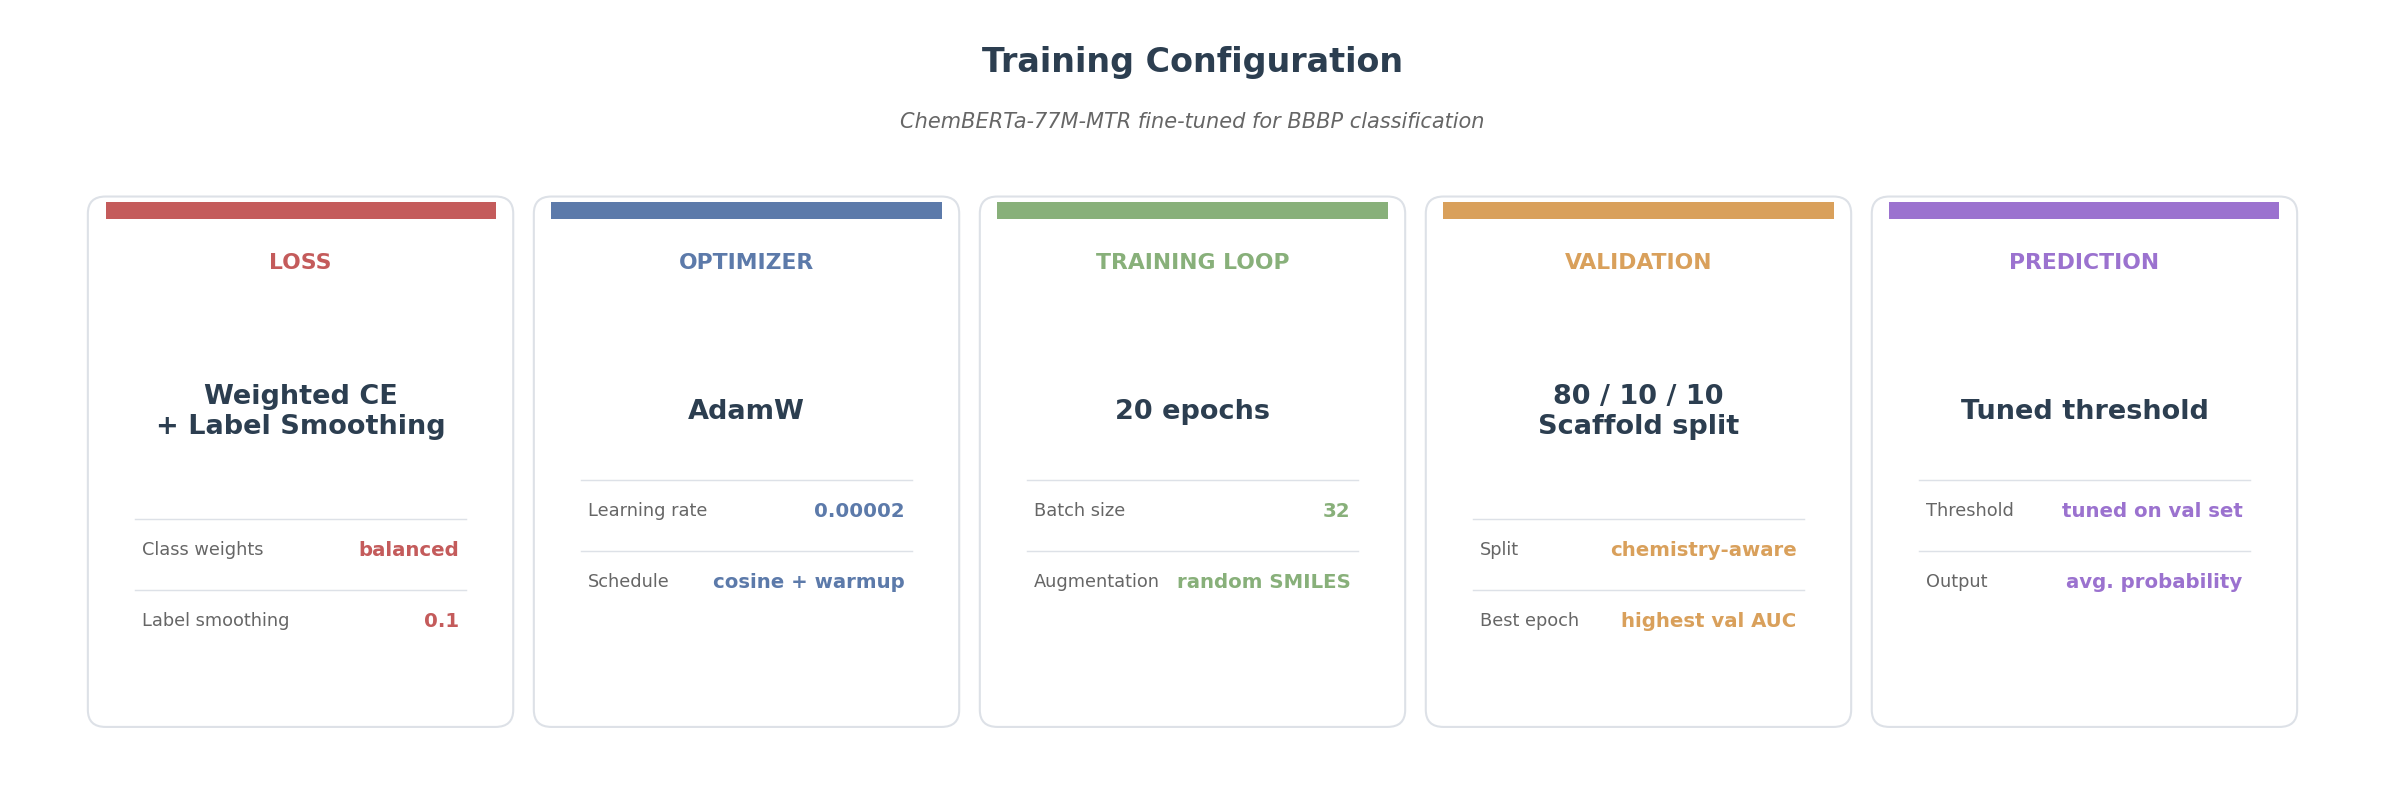

In [21]:
# === Visualization: Training configuration ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

EDGE, TEXT_DIM, LINE_LIGHT = "#2c3e50", "#666", "#dde1e7"

CARDS = [
    ("LOSS", "#C45B5B",
     "Weighted CE\n+ Label Smoothing",
     [("Class weights", "balanced"),
      ("Label smoothing", "0.1")]),
    ("OPTIMIZER", "#5C7AAA",
     "AdamW",
     [("Learning rate", "0.00002"),
      ("Schedule", "cosine + warmup")]),
    ("TRAINING LOOP", "#88B07A",
     "20 epochs",
     [("Batch size", "32"),
      ("Augmentation", "random SMILES")]),
    ("VALIDATION", "#D9A05B",
     "80 / 10 / 10\nScaffold split",
     [("Split", "chemistry-aware"),
      ("Best epoch", "highest val AUC")]),
    ("PREDICTION", "#9B72CF",
     "Tuned threshold",
     [("Threshold", "tuned on val set"),
      ("Output", "avg. probability")]),
]

fig, ax = plt.subplots(figsize=(16, 5.5), dpi=150)
ax.set_xlim(0, 16); ax.set_ylim(0, 5.5); ax.axis("off")

ax.text(8, 5.1, "Training Configuration", ha="center",
        fontsize=16, fontweight="bold", color=EDGE)
ax.text(8, 4.7, "ChemBERTa-77M-MTR fine-tuned for BBBP classification",
        ha="center", fontsize=10, style="italic", color=TEXT_DIM)

n = len(CARDS)
card_w, gap = 2.85, 0.18
total_w = n * card_w + (n - 1) * gap
start_x = (16 - total_w) / 2
card_y, card_h = 0.5, 3.7

for i, (title, dark, headline, details) in enumerate(CARDS):
    x = start_x + i * (card_w + gap)
    ax.add_patch(FancyBboxPatch((x, card_y), card_w, card_h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="white", edgecolor=LINE_LIGHT, linewidth=1.0))
    ax.add_patch(Rectangle((x + 0.1, card_y + card_h - 0.14), card_w - 0.2, 0.12,
                            facecolor=dark, edgecolor="none"))
    ax.text(x + card_w/2, card_y + card_h - 0.45, title,
            ha="center", va="center", fontsize=10.5, fontweight="bold", color=dark)
    headline_y = card_y + card_h - 1.5
    ax.text(x + card_w/2, headline_y, headline,
            ha="center", va="center", fontsize=13, fontweight="bold", color=EDGE)
    n_lines = headline.count("\n") + 1
    hl_box_h = 0.55 * n_lines + 0.25
    detail_top = headline_y - hl_box_h/2 - 0.3
    for j, (label, value) in enumerate(details):
        dy = detail_top - j * 0.5
        ax.plot([x + 0.3, x + card_w - 0.3], [dy + 0.22, dy + 0.22],
                color=LINE_LIGHT, linewidth=0.7)
        ax.text(x + 0.35, dy, label, ha="left", va="center", fontsize=8.5, color=TEXT_DIM)
        ax.text(x + card_w - 0.35, dy, value, ha="right", va="center",
                fontsize=9.5, fontweight="bold", color=dark)

plt.tight_layout()
plt.savefig("chemberta_training.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

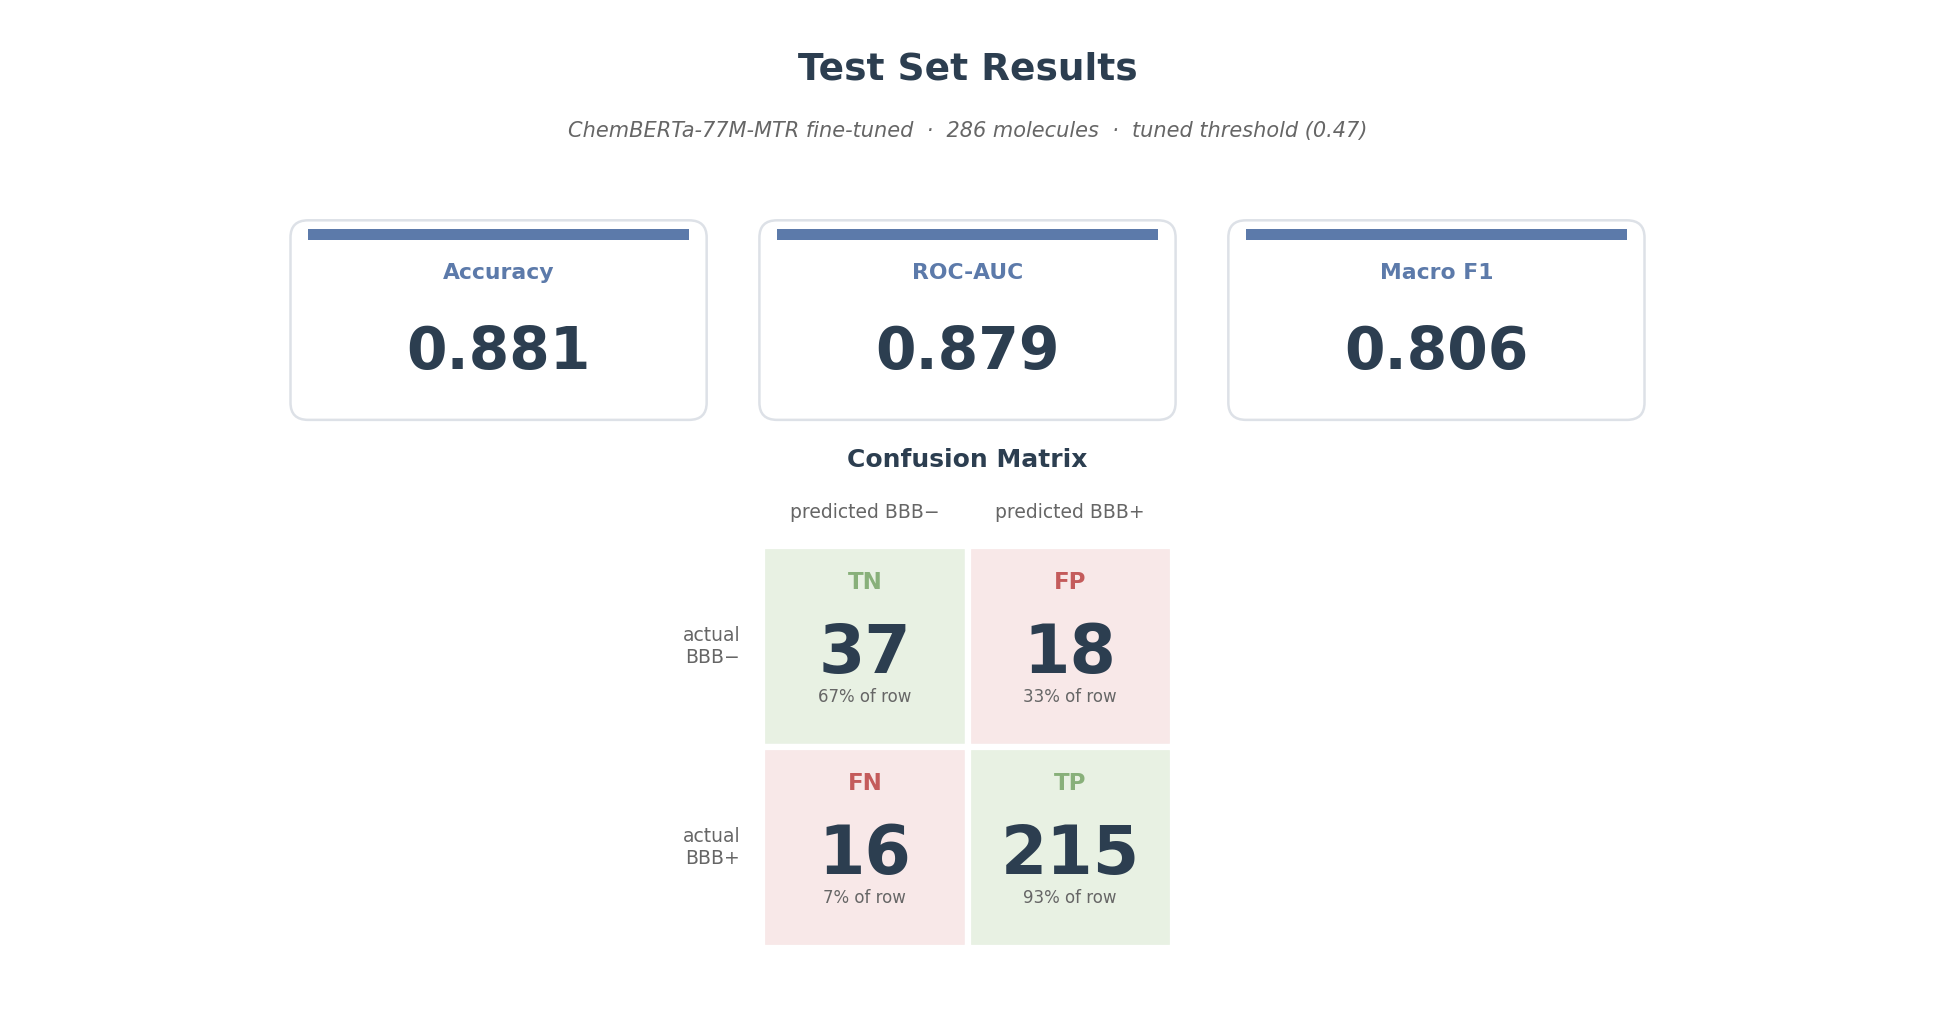

In [22]:
# === Visualization: Test set results summary ===
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.patches import Rectangle, FancyBboxPatch
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              roc_auc_score, f1_score)

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

EDGE         = "#2c3e50"
TEXT_DIM     = "#666"
LINE_LIGHT   = "#dde1e7"
COL_METRIC   = "#5C7AAA"
COL_CORRECT  = "#88B07A"
COL_WRONG    = "#C45B5B"
COL_BG_GREEN = "#E8F1E3"
COL_BG_RED   = "#F8E8E8"

# Gebruik de variabelen die de notebook al heeft staan
# Use tuned-threshold predictions already computed above
probs   = test_probs
y_true  = test_labels_eval
y_pred  = y_pred_tuned
cm      = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
n_total = len(y_true)
acc     = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, probs)
mf1     = f1_score(y_true, y_pred, average="macro")

fig, ax = plt.subplots(figsize=(13, 7), dpi=150)
ax.set_xlim(0, 13); ax.set_ylim(0, 7); ax.axis("off")

ax.text(6.5, 6.55, "Test Set Results",
        ha="center", fontsize=18, fontweight="bold", color=EDGE)
ax.text(6.5, 6.15,
        f"ChemBERTa-77M-MTR fine-tuned  ·  {n_total} molecules  ·  "
        f"tuned threshold ({best_threshold:.2f})",
        ha="center", fontsize=10, style="italic", color=TEXT_DIM)

metrics = [("Accuracy", acc), ("ROC-AUC", roc_auc), ("Macro F1", mf1)]
card_w, card_h, gap = 2.8, 1.35, 0.4
total_w = 3 * card_w + 2 * gap
start_x = (13 - total_w) / 2
card_y = 4.2

for i, (label, value) in enumerate(metrics):
    x = start_x + i * (card_w + gap)
    ax.add_patch(FancyBboxPatch((x, card_y), card_w, card_h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="white", edgecolor=LINE_LIGHT, linewidth=1.2))
    ax.add_patch(Rectangle((x + 0.1, card_y + card_h - 0.12), card_w - 0.2, 0.08,
                            facecolor=COL_METRIC, edgecolor="none"))
    ax.text(x + card_w/2, card_y + card_h - 0.35, label,
            ha="center", va="center", fontsize=10.5, fontweight="bold", color=COL_METRIC)
    ax.text(x + card_w/2, card_y + 0.45, f"{value:.3f}",
            ha="center", va="center", fontsize=28, fontweight="bold", color=EDGE)

cm_size = 2.8
cm_cell = cm_size / 2
cm_x = (13 - cm_size) / 2
cm_y = 0.5

ax.text(cm_x + cm_size/2, 3.85, "Confusion Matrix",
        ha="center", fontsize=12, fontweight="bold", color=EDGE)
ax.text(cm_x + cm_cell/2,     3.50, "predicted BBB−", ha="center", fontsize=9, color=TEXT_DIM)
ax.text(cm_x + cm_cell * 1.5, 3.50, "predicted BBB+", ha="center", fontsize=9, color=TEXT_DIM)
ax.text(cm_x - 0.15, cm_y + cm_cell * 1.5, "actual\nBBB−",
        ha="right", va="center", fontsize=9, color=TEXT_DIM)
ax.text(cm_x - 0.15, cm_y + cm_cell / 2, "actual\nBBB+",
        ha="right", va="center", fontsize=9, color=TEXT_DIM)

cells = [
    (0, 1, tn, "TN", COL_CORRECT, COL_BG_GREEN),
    (1, 1, fp, "FP", COL_WRONG,   COL_BG_RED),
    (0, 0, fn, "FN", COL_WRONG,   COL_BG_RED),
    (1, 0, tp, "TP", COL_CORRECT, COL_BG_GREEN),
]
for col, row, count, label, accent, bg in cells:
    x = cm_x + col * cm_cell
    y = cm_y + row * cm_cell
    ax.add_patch(Rectangle((x, y), cm_cell, cm_cell, facecolor=bg, edgecolor="white", linewidth=3))
    ax.text(x + cm_cell/2, y + cm_cell - 0.25, label, ha="center", va="center",
            fontsize=11, fontweight="bold", color=accent)
    ax.text(x + cm_cell/2, y + cm_cell/2 - 0.05, f"{count}", ha="center", va="center",
            fontsize=32, fontweight="bold", color=EDGE)
    row_total = (tn + fp) if row == 1 else (fn + tp)
    pct = count / row_total * 100 if row_total else 0
    ax.text(x + cm_cell/2, y + 0.35, f"{pct:.0f}% of row",
            ha="center", va="center", fontsize=8, color=TEXT_DIM)

plt.tight_layout()
plt.savefig("chemberta_eval.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()